In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

# ── 读取 AML 样本 ─────────────────────────────────────────
# dem.txt.gz 是基因×细胞的表达矩阵，行是基因，列是细胞
aml = pd.read_csv(
    r'D:\Bio-Informatics Case Study\M2_scRNAseq\data\GSM3587923_AML1012-D0.dem.txt.gz',
    sep='\t', index_col=0
)

# ── 读取正常骨髓样本 ──────────────────────────────────────
bm = pd.read_csv(
    r'D:\Bio-Informatics Case Study\M2_scRNAseq\data\GSM3587996_BM1.dem.txt.gz',
    sep='\t', index_col=0
)

print(f"AML 样本：{aml.shape[0]} 个基因，{aml.shape[1]} 个细胞")
print(f"正常骨髓：{bm.shape[0]} 个基因，{bm.shape[1]} 个细胞")
print(f"\nAML 数据预览：")
print(aml.iloc[:3, :3])

AML 样本：27899 个基因，1136 个细胞
正常骨髓：27899 个基因，108 个细胞

AML 数据预览：
          AML1012-D0_AAAAAGTTACGT  AML1012-D0_AAAACACCAATC  \
Gene                                                         
A1BG                            1                        0   
A1BG-AS1                        0                        0   
A1CF                            0                        0   

          AML1012-D0_AAAATAGCCTTT  
Gene                               
A1BG                            0  
A1BG-AS1                        0  
A1CF                            0  


In [3]:
# ── 转换为 AnnData 格式 ───────────────────────────────────
# Scanpy 要求：行=细胞，列=基因（和 pandas 读进来的方向相反，需要转置）

# 转置：行列互换
aml_t = aml.T
bm_t  = bm.T

# 创建 AnnData 对象
adata_aml = sc.AnnData(aml_t)
adata_bm  = sc.AnnData(bm_t)

# 添加样本标签，后面合并后能区分来源
adata_aml.obs['sample'] = 'AML1012-D0'
adata_aml.obs['condition'] = 'AML'

adata_bm.obs['sample'] = 'BM1'
adata_bm.obs['condition'] = 'Normal'

# 合并两个样本
adata = sc.concat([adata_aml, adata_bm], join='inner')

print(f"合并后：{adata.n_obs} 个细胞，{adata.n_vars} 个基因")
print(f"\n样本分布：")
print(adata.obs['condition'].value_counts())

合并后：1244 个细胞，27899 个基因

样本分布：
condition
AML       1136
Normal     108
Name: count, dtype: int64


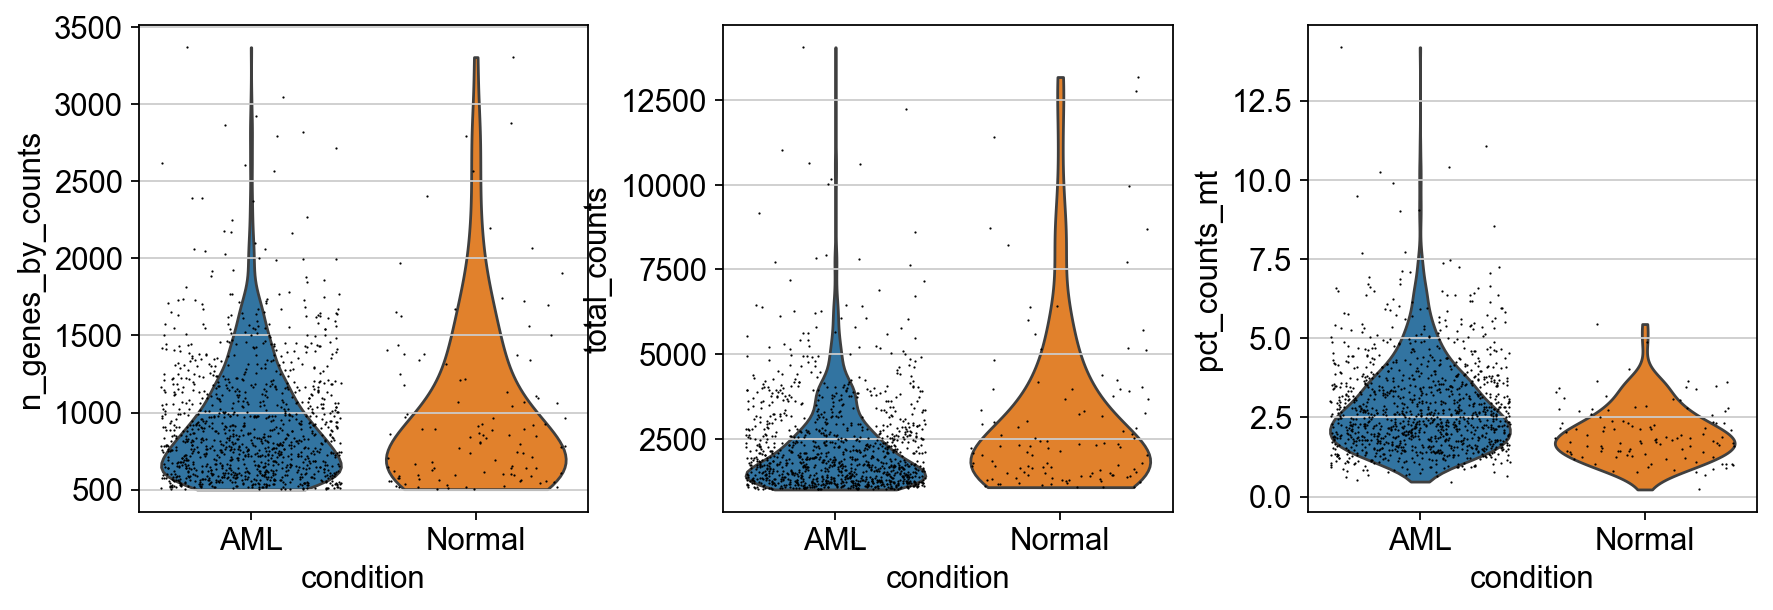

In [4]:
# ── 质量控制 ──────────────────────────────────────────────
# 标注线粒体基因
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# 计算 QC 指标
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# 可视化 QC 分布
sc.pl.violin(adata, 
             ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, groupby='condition')

In [5]:
# ── 过滤 + 标准化 + 高变基因 ──────────────────────────────
# 过滤低质量细胞（阈值放宽，因为数据已预处理）
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.filter_cells(adata, min_genes=200)
adata = adata[adata.obs.pct_counts_mt < 15, :]

print(f"过滤后：{adata.n_obs} 个细胞，{adata.n_vars} 个基因")

# 标准化
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# 存档原始数据
adata.raw = adata

# 筛选高变基因
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
print(f"高变基因：{adata.var.highly_variable.sum()} 个")

# 只保留高变基因
adata = adata[:, adata.var.highly_variable]

# 缩放
sc.pp.scale(adata, max_value=10)

# PCA
sc.tl.pca(adata, svd_solver='arpack')

# 邻居图 + UMAP + 聚类
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=20)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5, flavor="igraph", n_iterations=2)

print("分析完成！")
print(f"Leiden 聚类数：{adata.obs['leiden'].nunique()} 个")

filtered out 14387 genes that are detected in less than 3 cells
过滤后：1244 个细胞，13512 个基因
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes


D:\miniconda3\envs\scrna\Lib\site-packages\scanpy\preprocessing\_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
高变基因：3149 个


D:\miniconda3\envs\scrna\Lib\site-packages\scanpy\preprocessing\_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 20


D:\miniconda3\envs\scrna\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\miniconda3\envs\scrna\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\miniconda3\envs\scrna\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "D:\miniconda3\envs\scrna\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\miniconda3\envs\scrna\Lib\subprocess.

    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:16)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:03)
running Leiden clustering
    finished: found 6 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
分析完成！
Leiden 聚类数：6 个


C:\Users\30933\AppData\Local\Temp\ipykernel_34832\1709400947.py:14: UserWarning: Glyph 32858 (\N{CJK UNIFIED IDEOGRAPH-805A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\30933\AppData\Local\Temp\ipykernel_34832\1709400947.py:14: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\30933\AppData\Local\Temp\ipykernel_34832\1709400947.py:14: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\30933\AppData\Local\Temp\ipykernel_34832\1709400947.py:14: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\30933\AppData\Local\Temp\ipykernel_34832\1709400947.py:14: UserWarning: Glyph 39592 (\N{CJK UNIFIED IDEOGRAPH-9AA8}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\30933\AppData\Local\Temp\ipykernel_34832\1709400947.py:14: UserWarning: Glyph 39635 (\N{CJK UNIFIED IDEOGRAPH-9AD3})

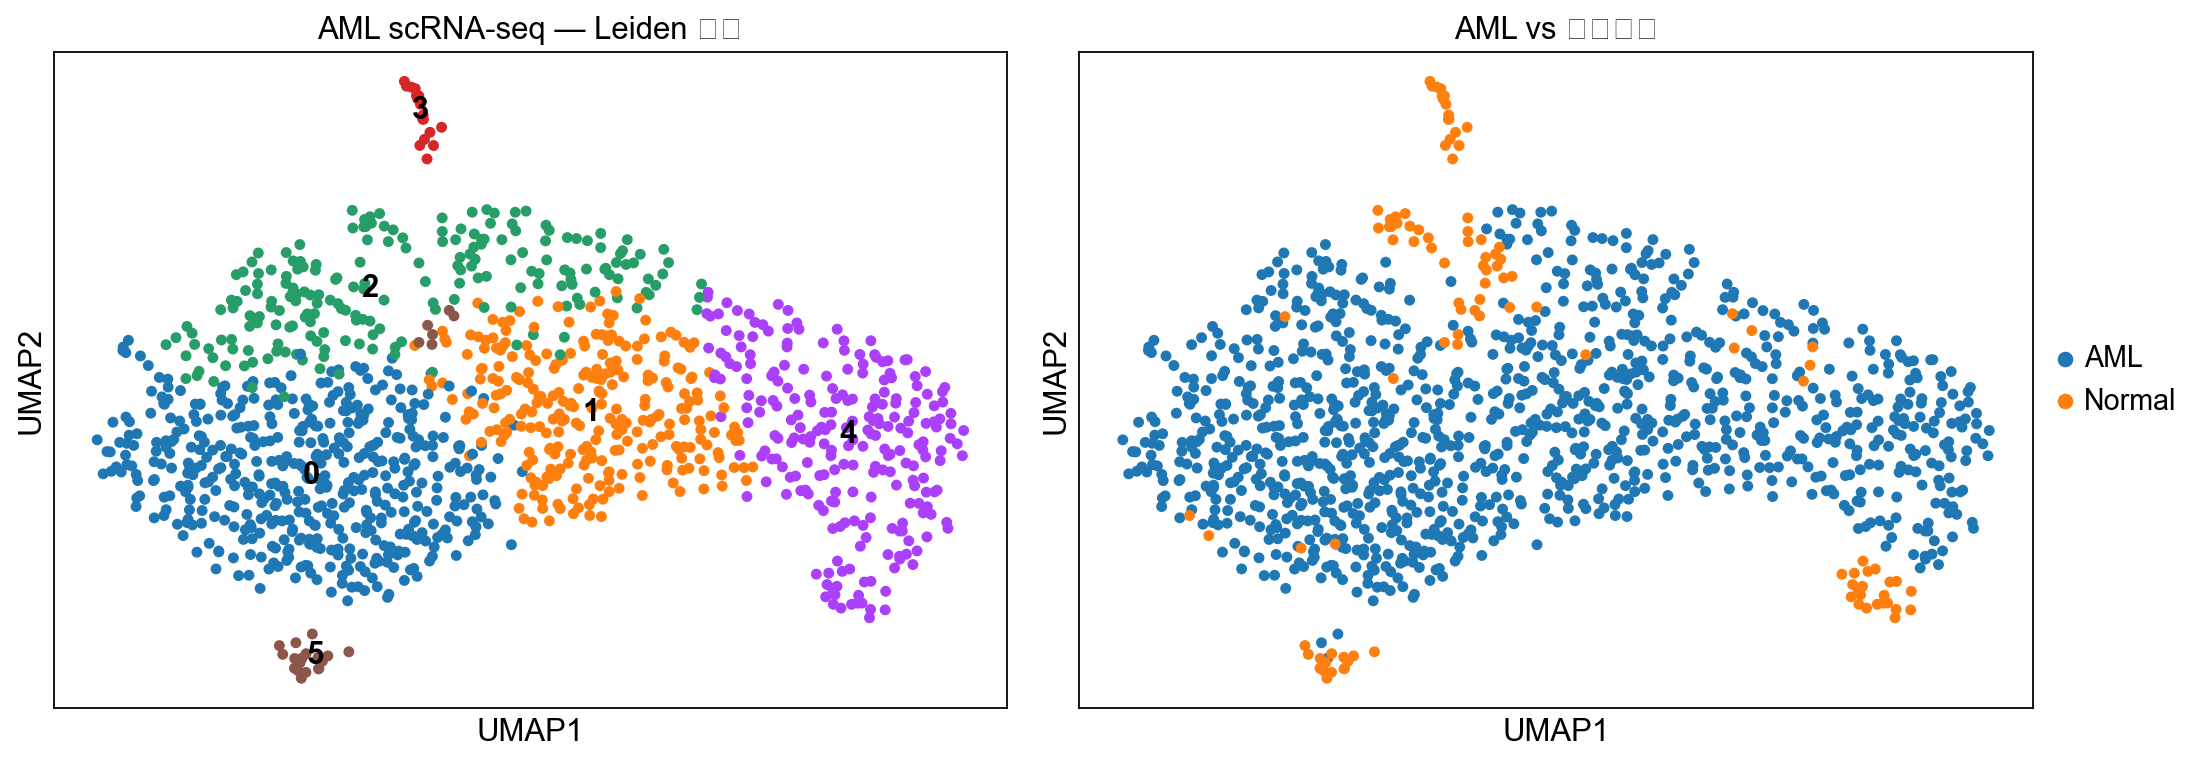

UMAP 图已保存


In [6]:
# ── 画 UMAP ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：按 Leiden 聚类编号上色
sc.pl.umap(adata, color='leiden', 
           title='AML scRNA-seq — Leiden 聚类',
           legend_loc='on data', ax=axes[0], show=False)

# 右图：按 AML vs Normal 上色
sc.pl.umap(adata, color='condition',
           title='AML vs 正常骨髓',
           ax=axes[1], show=False)

plt.tight_layout()
plt.savefig(r'D:\Bio-Informatics Case Study\M2_scRNAseq\UMAP_AML_clusters.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("UMAP 图已保存")

In [7]:
import warnings
import matplotlib
warnings.filterwarnings('ignore')  # 压制所有 warning

# 重新设置字体，指定 savefig 也用中文字体
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['savefig.dpi'] = 150

# 专门解决 savefig 时的字体问题
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

print("Warning 压制完成，字体设置完成")

Warning 压制完成，字体设置完成


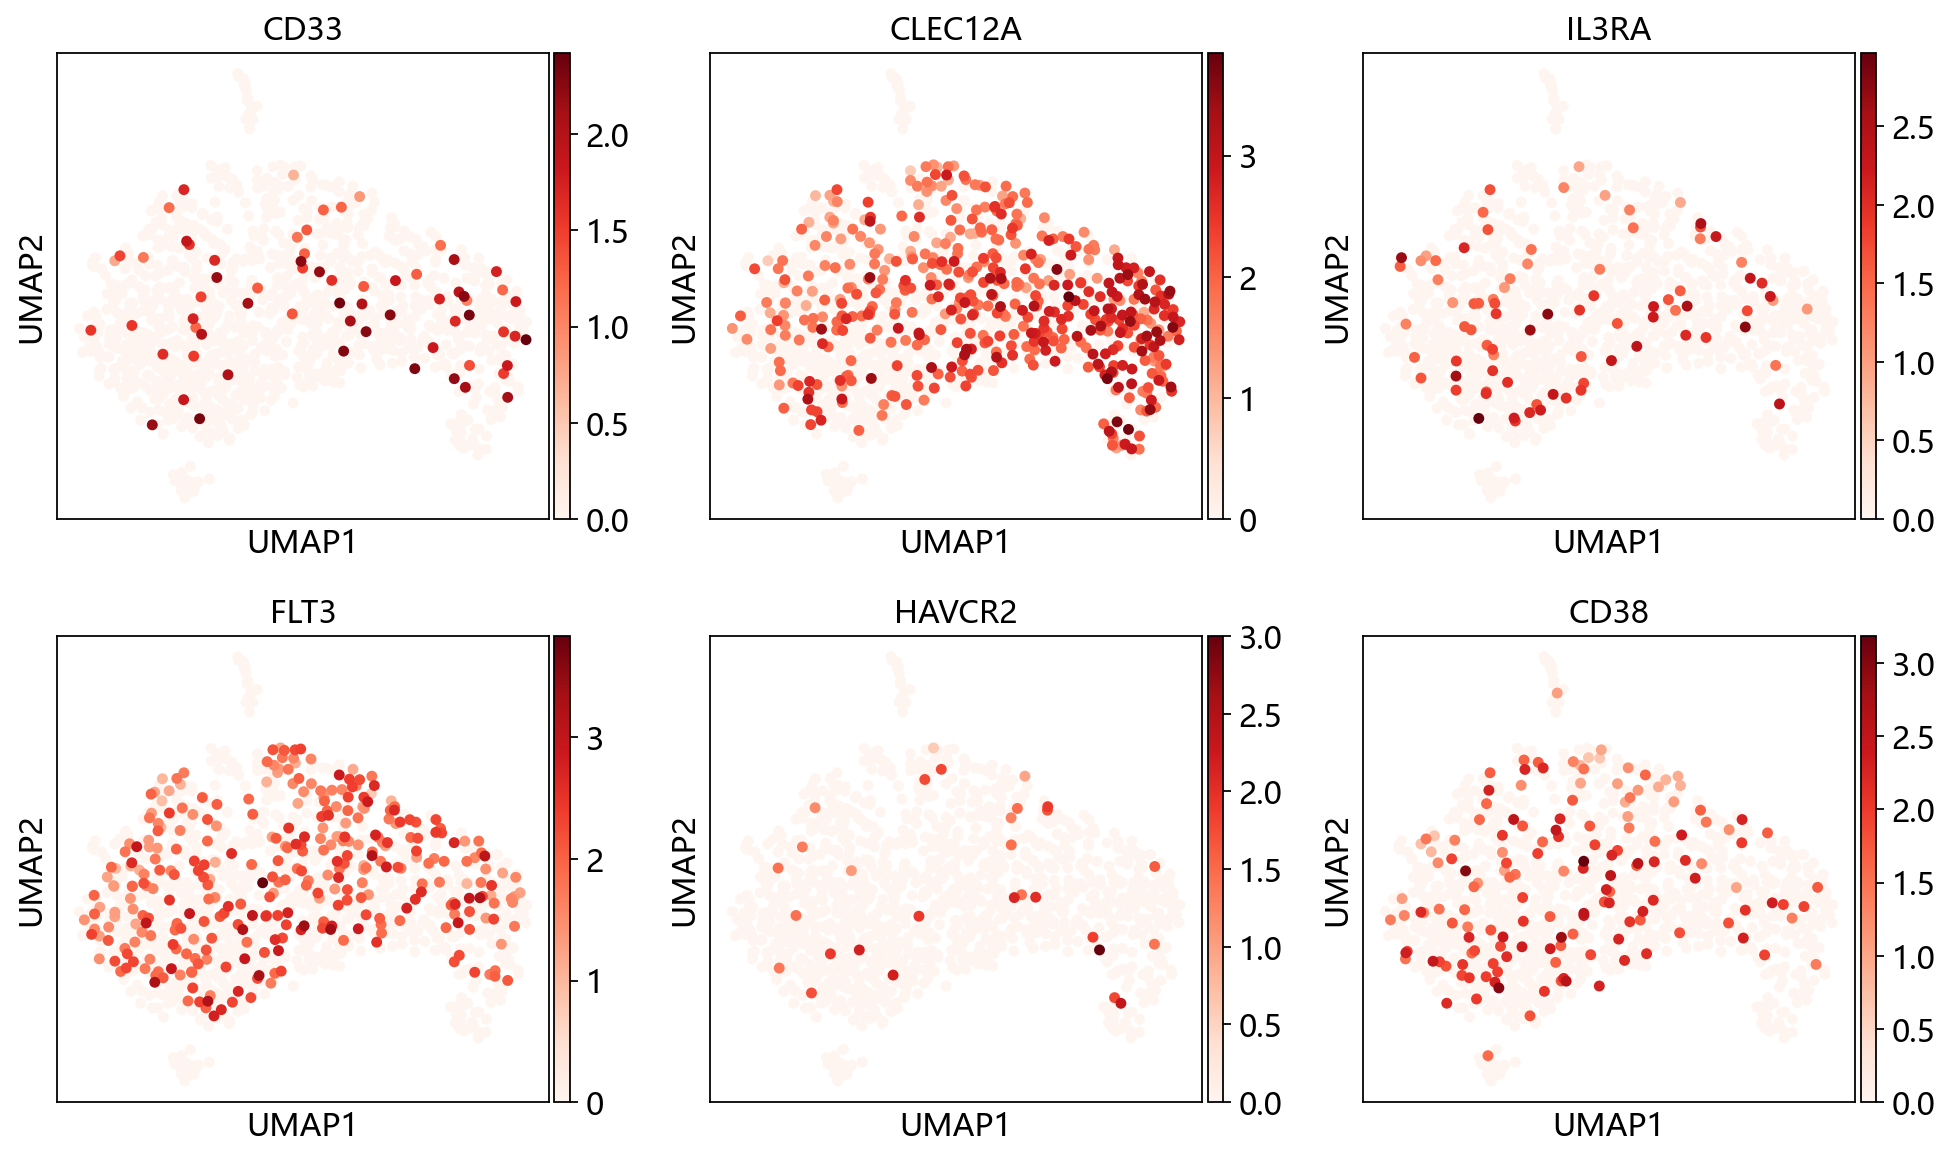

In [8]:
# ── 可视化已知 AML CAR-T 靶点基因的表达 ──────────────────
# 在 UMAP 上直接看这些基因在哪些细胞里高表达

cart_targets = ['CD33', 'CLEC12A', 'IL3RA', 'FLT3', 'HAVCR2', 'CD38']

sc.pl.umap(adata.raw.to_adata(), 
           color=cart_targets,
           ncols=3,
           cmap='Reds',
           use_raw=False)

In [9]:
# ── 定量比较 AML vs Normal 各靶点表达 ────────────────────
raw_adata = adata.raw.to_adata()
raw_adata.obs['condition'] = adata.obs['condition']

results = []
for gene in cart_targets:
    if gene in raw_adata.var_names:
        aml_expr    = raw_adata[raw_adata.obs.condition == 'AML', gene].X.mean()
        normal_expr = raw_adata[raw_adata.obs.condition == 'Normal', gene].X.mean()
        fold_change = aml_expr / (normal_expr + 0.01)  # 避免除以0
        results.append({
            '基因': gene,
            'AML平均表达': round(float(aml_expr), 3),
            '正常骨髓平均表达': round(float(normal_expr), 3),
            'AML/Normal倍数': round(float(fold_change), 2),
            'CAR-T靶点潜力': '⭐⭐⭐' if fold_change > 2 else ('⭐⭐' if fold_change > 1.2 else '⭐')
        })

df_targets = pd.DataFrame(results).sort_values('AML/Normal倍数', ascending=False)
print("=== AML CAR-T 候选靶点定量分析 ===\n")
print(df_targets.to_string(index=False))

=== AML CAR-T 候选靶点定量分析 ===

     基因  AML平均表达  正常骨髓平均表达  AML/Normal倍数 CAR-T靶点潜力
   FLT3    0.574     0.044         10.54       ⭐⭐⭐
   CD33    0.099     0.000          9.92       ⭐⭐⭐
  IL3RA    0.124     0.035          2.73       ⭐⭐⭐
CLEC12A    0.878     0.408          2.10       ⭐⭐⭐
   CD38    0.222     0.148          1.41        ⭐⭐
 HAVCR2    0.037     0.054          0.58         ⭐
